
Processing: 10.48550/arXiv.2603.23024
[arXiv] ID found: 2603.23024

==== SUMMARY ====
Processed successfully: 1
Failed: 0
Total: 1

Processed documents:

1. 10.48550/arXiv.2603.23024 [arxiv]

Document: Heart Failure’s First Shock and Nurse-Led Chronic Care

Source:
- arxiv

Authors:
- Moslem Rashidi
- Luke Brian Connelly
- Gianluca Fiorentini

Emails:
- moslem.rashidi2@unibo.it (corresponding)
- l.connelly@uq.edu.au
- luke.connelly@unibo.it
- gianluca.fiorentini@unibo.it

Available sections:

1. 1 Introduction
2. 2 Background and Institutional Setting
3. 3 Economic Framework
4. 4 Data and Identification
5. 4.1 Empirical Design
6. 5 Results
7. 6 Conclusion
8. Appendix A: Structural Health-Capital Model and Event-Study Mapping
9. Appendix B: Data and Identification
10. Appendix C: Moving Average Graphs
11. Appendix D: Additional Empirical Design Details
12. Appendix E: Estimation Graphs
13. Appendix F: Tables
14. Acknowledgements
15. Declaration
16. Data statement
17. Generative AI decl

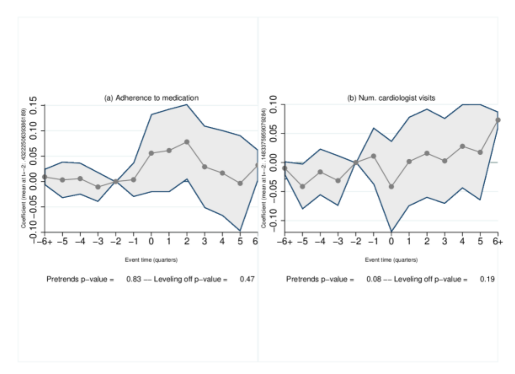


[Image 2] Figure 3 : HonestDiD sensitivity analysis (Rambachan and Roth, 2023) for the Sun–Abraham estimates. The figure reports 95% confidence intervals across M ∈ { 0 , 0.5 , 1 , 1.5 , 2 } M\in\{0,0.5,1,1.5,2\} , where larger M M permits larger departures from parallel trends.
Path: paper_pipeline_data\png\10.48550/arXiv.2603.23024\x4.png



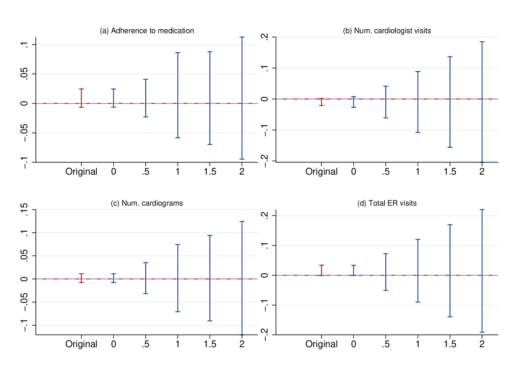


Processed documents:

1. 10.48550/arXiv.2603.23024 [arxiv]

Processed documents:

1. 10.48550/arXiv.2603.23024 [arxiv]


In [2]:
import os
import re
import io
import json
import time
import gzip
import tarfile
import requests
import xml.etree.ElementTree as ET

from bs4 import BeautifulSoup
from urllib.parse import urlparse
from PIL import Image
import matplotlib.pyplot as plt
from tabulate import tabulate

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


# =========================================================
# CONFIG
# =========================================================

BASE_DIR = "paper_pipeline_data"

MD_DIR = os.path.join(BASE_DIR, "md")
PDF_DIR = os.path.join(BASE_DIR, "pdf")
PNG_DIR = os.path.join(BASE_DIR, "png")
HTML_DIR = os.path.join(BASE_DIR, "html")
META_DIR = os.path.join(BASE_DIR, "meta")

for d in [MD_DIR, PDF_DIR, PNG_DIR, HTML_DIR, META_DIR]:
    os.makedirs(d, exist_ok=True)

SESSION = requests.Session()
HEADERS = {"User-Agent": "Mozilla/5.0"}
MAX_HTTP_RETRIES = 5


# =========================================================
# UTILS
# =========================================================

def normalize(text):
    return re.sub(r"\s+", " ", text or "").strip()


def save_text(data, path):
    with open(path, "w", encoding="utf-8") as f:
        f.write(data)


def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def load_json(path, default=None):
    if not os.path.exists(path):
        return {} if default is None else default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def show_image(path):
    try:
        img = Image.open(path)
        plt.figure()
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"[IMG ERROR] {e}")


def textify(elem):
    if elem is None:
        return ""

    parts = [elem.text or ""]
    for c in elem:
        parts.append(textify(c))
        if c.tail:
            parts.append(c.tail)

    return normalize("".join(parts))


# =========================================================
# COMMON TABLE PARSING
# =========================================================

def parse_md_table(text):
    lines = [l.strip() for l in text.split("\n") if l.strip().startswith("|")]

    if len(lines) < 2:
        return None

    def split_row(line):
        cells = [x.strip() for x in line.split("|")]
        if cells and cells[0] == "":
            cells = cells[1:]
        if cells and cells[-1] == "":
            cells = cells[:-1]
        return cells

    rows_raw = [split_row(line) for line in lines]

    header = rows_raw[0]
    max_width = len(header)

    data = []
    for r in rows_raw[1:]:
        if all(re.fullmatch(r"-+", cell or "") for cell in r):
            continue

        if len(r) < max_width:
            r += [""] * (max_width - len(r))
        elif len(r) > max_width:
            r = r[:max_width]

        data.append(r)

    return header, data


# =========================================================
# SELENIUM FOR PMC
# =========================================================

def get_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--disable-infobars")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    return driver


def fetch_real_html_pmc(pmcid):
    driver = get_driver()
    url = f"https://pmc.ncbi.nlm.nih.gov/articles/{pmcid}/"

    print(f"Opening browser for {pmcid}...")
    driver.get(url)

    print("Waiting for rendered content / anti-bot redirect...")
    time.sleep(10)

    html = driver.page_source
    driver.quit()
    return html


# =========================================================
# PMC HELPERS
# =========================================================

def doi_to_pmcid(doi):
    url = "https://pmc.ncbi.nlm.nih.gov/tools/idconv/api/v1/articles/"
    params = {"ids": doi, "format": "json"}

    for _ in range(MAX_HTTP_RETRIES):
        try:
            r = SESSION.get(url, params=params, headers=HEADERS, timeout=30)
            data = r.json()
            if data.get("records"):
                return data["records"][0].get("pmcid")
        except Exception:
            pass
        time.sleep(1)

    return None


def fetch_pmc_xml(pmcid):
    pmc_num = pmcid[3:]

    url = "https://pmc.ncbi.nlm.nih.gov/api/oai/v1/mh/"
    params = {
        "verb": "GetRecord",
        "identifier": f"oai:pubmedcentral.nih.gov:{pmc_num}",
        "metadataPrefix": "pmc",
    }

    for _ in range(MAX_HTTP_RETRIES):
        try:
            r = SESSION.get(url, params=params, headers=HEADERS, timeout=60)
            if r.status_code == 200:
                return r.text
        except Exception:
            pass
        time.sleep(1)

    return None


def extract_pmc_image_urls_from_rendered_html(html):
    """
    Extract figure image URLs from rendered PMC HTML.
    Prefer <figure> / .fig images; fallback to regex.
    """
    soup = BeautifulSoup(html, "html.parser")
    urls = []

    selectors = [
        "figure img",
        ".fig img",
        "div.fig img",
        "img"
    ]

    for selector in selectors:
        for img in soup.select(selector):
            src = img.get("src") or img.get("data-src") or img.get("data-original")
            if not src:
                continue

            if src.startswith("//"):
                src = "https:" + src
            elif src.startswith("/"):
                src = "https://pmc.ncbi.nlm.nih.gov" + src

            if "cdn.ncbi.nlm.nih.gov/pmc/blobs/" in src and re.search(
                r"\.(jpg|jpeg|png|gif|tif|tiff|webp)(\?|$)", src, re.I
            ):
                urls.append(src)

    if not urls:
        urls = re.findall(
            r'https://cdn\.ncbi\.nlm\.nih\.gov/pmc/blobs/[^"\']+\.(?:jpg|jpeg|png|gif|tif|tiff|webp)(?:\?[^"\']*)?',
            html,
            flags=re.I
        )

    seen = set()
    out = []
    for u in urls:
        if u not in seen:
            seen.add(u)
            out.append(u)

    return out


def download_binary(url, path):
    r = SESSION.get(url, headers=HEADERS, timeout=60)
    r.raise_for_status()

    with open(path, "wb") as f:
        f.write(r.content)


def download_pmc_images(pmcid):
    """
    Fetch rendered HTML using Selenium, extract real image URLs, download them,
    and return ordered local paths.
    """
    html = fetch_real_html_pmc(pmcid)

    html_path = os.path.join(HTML_DIR, f"{pmcid}.html")
    save_text(html, html_path)

    urls = extract_pmc_image_urls_from_rendered_html(html)
    if not urls:
        return [], html_path

    doc_img_dir = os.path.join(PNG_DIR, pmcid)
    os.makedirs(doc_img_dir, exist_ok=True)

    local_paths = []

    for idx, url in enumerate(urls):
        try:
            filename = os.path.basename(urlparse(url).path)
            if not filename or "." not in filename:
                filename = f"pmc_image_{idx}.png"

            local_path = os.path.join(doc_img_dir, filename)

            if not os.path.exists(local_path):
                download_binary(url, local_path)

            local_paths.append(local_path)
            time.sleep(0.3)
        except Exception as e:
            print(f"[PMC IMG FAIL] {url} -> {e}")

    return local_paths, html_path


def parse_pmc_table(table):
    if table is None:
        return None

    rows = []

    thead = table.find(".//{*}thead")
    if thead is not None:
        for tr in thead.findall("{*}tr"):
            header_row = [textify(td) for td in tr.findall("{*}th")]
            if header_row:
                rows.append(header_row)

    tbody = table.find(".//{*}tbody")
    if tbody is not None:
        for tr in tbody.findall("{*}tr"):
            body_row = [textify(td) for td in tr.findall("{*}td")]
            if body_row:
                rows.append(body_row)

    if not rows:
        # fallback: try plain tr
        for tr in table.findall(".//{*}tr"):
            cells = [textify(td) for td in tr.findall("{*}th")] + [textify(td) for td in tr.findall("{*}td")]
            if cells:
                rows.append(cells)

    if not rows:
        return None

    header = rows[0]

    md = []
    md.append("| " + " | ".join(header) + " |")
    md.append("| " + " | ".join("---" for _ in header) + " |")

    for r in rows[1:]:
        if len(r) < len(header):
            r += [""] * (len(header) - len(r))
        elif len(r) > len(header):
            r = r[:len(header)]
        md.append("| " + " | ".join(r) + " |")

    return "\n".join(md)


def parse_pmc_article_to_markdown(xml):
    """
    Build markdown from PMC XML.
    Figures are inserted as placeholders:
    ![caption](PMC_FIG_0), ![caption](PMC_FIG_1), ...
    Later interactive_view maps them to downloaded local files.
    """
    root = ET.fromstring(xml)
    article = root.find(".//{*}article")

    if article is None:
        return None

    out = []

    title = article.find(".//{*}article-title")
    if title is not None:
        out.append(f"# {textify(title)}\n")

    body = article.find("{*}body")
    if body is None:
        return "\n".join(out)

    fig_counter = 0

    for sec in body.findall(".//{*}sec"):
        sec_title = sec.find("{*}title")
        if sec_title is not None:
            out.append(f"\n## {textify(sec_title)}\n")

        # paragraph text directly under this section
        for p in sec.findall("{*}p"):
            txt = textify(p)
            if txt:
                out.append(txt + "\n")

        # figures under this section
        for fig in sec.findall(".//{*}fig"):
            label = textify(fig.find("{*}label"))
            caption = textify(fig.find(".//{*}caption"))
            alt = normalize(f"{label} {caption}")

            out.append(f"\n![{alt}](PMC_FIG_{fig_counter})\n")
            fig_counter += 1

        # tables under this section
        for tbl_wrap in sec.findall(".//{*}table-wrap"):
            label = tbl_wrap.find("{*}label")
            caption = tbl_wrap.find(".//{*}caption")
            table = tbl_wrap.find("{*}table")

            if label is not None:
                out.append(f"\n**{textify(label)}**\n")

            if caption is not None:
                out.append(f"*{textify(caption)}*\n")

            md_table = parse_pmc_table(table)
            if md_table:
                out.append(md_table + "\n")

    return "\n".join(out)


def clean_markdown(md_text):
    lines = md_text.split("\n")

    cleaned = []
    current_section = None
    current_content = []
    seen_sections = set()

    def flush():
        nonlocal current_section, current_content

        if current_section:
            content = "\n".join(current_content).strip()
            if content:
                key = normalize(current_section.lower() + content[:200])
                if key not in seen_sections:
                    seen_sections.add(key)
                    cleaned.append(current_section)
                    cleaned.append(content)
                    cleaned.append("")

        current_section = None
        current_content = []

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("## "):
            flush()
            current_section = stripped
        else:
            if current_section:
                current_content.append(line)
            else:
                cleaned.append(line)

    flush()
    return "\n".join(cleaned)


def extract_pmc_authors_emails(xml):
    root = ET.fromstring(xml)

    authors = []
    emails = []

    for c in root.findall(".//{*}contrib[@contrib-type='author']"):
        g = c.find(".//{*}given-names")
        s = c.find(".//{*}surname")

        if g is not None and s is not None:
            authors.append(normalize(f"{g.text} {s.text}"))

        e = c.find(".//{*}email")
        if e is not None and e.text:
            emails.append(normalize(e.text))

    authors = list(dict.fromkeys([a for a in authors if a]))
    emails = list(dict.fromkeys([e for e in emails if e]))

    return authors, emails


# =========================================================
# ARXIV HELPERS
# =========================================================

def is_arxiv_identifier(text):
    low = text.lower()
    return "arxiv" in low or re.search(r"\b\d{4}\.\d{4,5}(v\d+)?\b", low) is not None


def doi_to_arxiv_id(doi):
    # Handles e.g. arXiv:2501.12345, arxiv.org/abs/2501.12345, doi-like strings containing arxiv
    m = re.search(r"(\d{4}\.\d{4,5})(v\d+)?", doi, flags=re.I)
    if m:
        return m.group(1)
    return None


def fetch_ar5iv_html(arxiv_id):
    url = f"https://ar5iv.org/html/{arxiv_id}"

    for _ in range(MAX_HTTP_RETRIES):
        try:
            r = SESSION.get(url, headers=HEADERS, timeout=60)
            if r.status_code == 200:
                return r.text
        except Exception:
            pass
        time.sleep(1)

    return None


def download_arxiv_source(arxiv_id):
    url = f"https://arxiv.org/e-print/{arxiv_id}"
    r = SESSION.get(url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    return r.content


def unpack_archive(content):
    files = {}

    try:
        with tarfile.open(fileobj=io.BytesIO(content), mode="r:*") as tar:
            for member in tar.getmembers():
                if member.isfile() and member.name.lower().endswith(".tex"):
                    extracted = tar.extractfile(member)
                    if extracted is None:
                        continue
                    files[member.name] = extracted.read().decode("utf-8", errors="ignore")
        if files:
            return files
    except tarfile.ReadError:
        pass

    try:
        text = gzip.decompress(content).decode("utf-8", errors="ignore")
        return {"main.tex": text}
    except Exception:
        return {}


def download_single_image(url, doc_id, idx):
    if url.startswith("/"):
        url = "https://ar5iv.org" + url

    img_dir = os.path.join(PNG_DIR, doc_id)
    os.makedirs(img_dir, exist_ok=True)

    try:
        filename = os.path.basename(urlparse(url).path)
        if not filename or "." not in filename:
            filename = f"image_{idx}.png"

        path = os.path.join(img_dir, filename)

        if not os.path.exists(path):
            r = SESSION.get(url, headers=HEADERS, timeout=30)
            if r.status_code != 200:
                return None
            with open(path, "wb") as f:
                f.write(r.content)

        return path
    except Exception:
        return None


# =========================================================
# ARXIV HTML -> MD
# =========================================================

def parse_html_table(table):
    rows = []

    for tr in table.find_all("tr"):
        cols = tr.find_all(["td", "th"])
        row = [normalize(c.get_text(" ", strip=True)) for c in cols]
        if row:
            rows.append(row)

    if not rows:
        return ""

    md = []
    md.append("| " + " | ".join(rows[0]) + " |")
    md.append("| " + " | ".join("---" for _ in rows[0]) + " |")

    for r in rows[1:]:
        if len(r) < len(rows[0]):
            r += [""] * (len(rows[0]) - len(r))
        elif len(r) > len(rows[0]):
            r = r[:len(rows[0])]
        md.append("| " + " | ".join(r) + " |")

    return "\n".join(md)


def parse_html_figure(fig):
    img = fig.find("img")
    caption = fig.find("figcaption")

    src = ""
    if img and img.has_attr("src"):
        src = img["src"]
        if src.startswith("/"):
            src = "https://ar5iv.org" + src

    cap = caption.get_text(" ", strip=True) if caption else ""
    return f"\n![{cap}]({src})\n"


def html_to_markdown_arxiv(html):
    soup = BeautifulSoup(html, "html.parser")
    article = soup.find("article")

    if not article:
        return None

    md = []

    for tag in article.find_all([
        "h1", "h2", "h3",
        "p", "li", "pre",
        "figure", "table"
    ]):
        text = normalize(tag.get_text(" ", strip=True))

        if tag.name == "h1":
            md.append(f"# {text}")
        elif tag.name == "h2":
            md.append(f"\n## {text}")
        elif tag.name == "h3":
            md.append(f"\n### {text}")
        elif tag.name == "p":
            if text:
                md.append(text)
        elif tag.name == "li":
            md.append(f"- {text}")
        elif tag.name == "pre":
            md.append(f"\n```\n{text}\n```")
        elif tag.name == "figure":
            md.append(parse_html_figure(tag))
        elif tag.name == "table":
            table_md = parse_html_table(tag)
            if table_md:
                md.append("\n" + table_md + "\n")

    return "\n\n".join(md)


# =========================================================
# ARXIV AUTHORS / EMAILS FROM TEX
# =========================================================

def extract_balanced_blocks(text, command):
    results = []
    pattern = re.compile(rf"\\{re.escape(command)}\s*\{{")

    for match in pattern.finditer(text):
        brace_start = match.end() - 1
        depth = 0
        end = None

        for i in range(brace_start, len(text)):
            char = text[i]
            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1
                if depth == 0:
                    end = i
                    break

        if end is not None:
            results.append(text[brace_start + 1:end])

    return results


def find_author_files(files):
    author_files = {}

    for filename, tex in files.items():
        blocks = extract_balanced_blocks(tex, "author")
        if blocks:
            author_files[filename] = blocks

    return author_files


def normalize_author_name(name):
    name = name.strip()
    name = re.sub(r"^(?:AND|And|and)\s+", "", name)
    name = re.sub(r"(?<=[A-Za-z])\s*\d{4}-\d{4}-\d{4}-\d{3,4}[0-9X]\b", "", name)
    name = re.sub(r"\b\d{4}-\d{4}-\d{4}-\d{3,4}[0-9X]\b", "", name)
    name = re.sub(r"\s*\.\s*mm\s*$", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s+mm\s*$", "", name, flags=re.IGNORECASE)
    name = re.sub(r"[^A-Za-z.\-'\s]", " ", name)
    name = re.sub(r"(?:\s*-\s*){2,}X?\s*$", "", name)
    name = re.sub(r"-{2,}X?\s*$", "", name)
    name = re.sub(r"(?:\s*-\s*)+X\s*$", "", name)
    name = re.sub(r"\s*-\s*$", "", name)
    name = re.sub(r"[-–—\s]+$", "", name)
    name = re.sub(r"\s+", " ", name).strip(" ,;")
    return name


def looks_like_person_name(line):
    line = line.strip(" ,;")
    if not line or "@" in line:
        return False

    low = line.lower()

    bad_keywords = [
        "university", "department", "institute", "school", "centre", "center",
        "lab", "labs", "laboratory", "faculty", "college",
        "research", "brain", "google", "openai", "meta", "microsoft",
        "amazon", "deepmind", "anthropic", "nvidia",
        "economics", "business", "law",
        "corresponding author", "email", "orcid", "https", "http"
    ]
    if any(k in low for k in bad_keywords):
        return False

    words = line.split()
    if len(words) < 2 or len(words) > 6:
        return False

    valid_words = 0
    for word in words:
        cleaned = re.sub(r"[^A-Za-z.\-']", "", word)
        if not cleaned:
            continue
        if cleaned[0].isupper():
            valid_words += 1

    if valid_words < 2:
        return False

    if len(line) > 60:
        return False

    return True


def clean_single_author_block(block):
    text = block.replace("\r", "\n")

    text = text.replace("\\\\", "\n")
    text = re.sub(r"\\and\b|\\And\b|\\AND\b", "\n", text)
    text = re.sub(r"\\quad\b|\\qquad\b", "\n", text)
    text = re.sub(r"\s+\band\b\s+", "\n", text, flags=re.IGNORECASE)

    prev = None
    while prev != text:
        prev = text
        text = re.sub(r"\\thanks\s*\{([^{}]|\{[^{}]*\})*\}", "", text)

    prev = None
    while prev != text:
        prev = text
        text = re.sub(r"\\footnote\s*\{([^{}]|\{[^{}]*\})*\}", "", text)

    text = re.sub(r"\$\^\{[^$]*\}\$", "", text)
    text = re.sub(r"\$[^$]*\$", "", text)

    prev = None
    while prev != text:
        prev = text
        text = re.sub(r"\\[A-Za-z*]+\s*\{([^{}]*)\}", r"\1", text)

    text = re.sub(r"\\[A-Za-z*]+", " ", text)
    text = text.replace("{", "").replace("}", "")

    raw_lines = []
    for line in text.splitlines():
        line = re.sub(r"\s+", " ", line).strip(" ,;")
        if line:
            raw_lines.append(line)

    candidates = []

    for line in raw_lines:
        comma_parts = [p.strip() for p in re.split(r"\s*,\s*", line) if p.strip()]
        normalized_parts = [normalize_author_name(p) for p in comma_parts]

        if len(comma_parts) > 1 and all(looks_like_person_name(p) for p in normalized_parts):
            candidates.extend(normalized_parts)
        else:
            candidates.append(normalize_author_name(line))

    authors = []
    seen = set()

    for cand in candidates:
        cand = normalize_author_name(cand)
        if looks_like_person_name(cand):
            key = cand.lower()
            if key not in seen:
                seen.add(key)
                authors.append(cand)

    return authors


def extract_emails_from_text(tex):
    emails = []

    grouped = re.findall(r"\{([^{}]+)\}\\?@([A-Za-z0-9.\-]+\.[A-Za-z]{2,})", tex)
    for users, domain in grouped:
        for user in users.split(","):
            user = user.strip().strip("\\")
            if user:
                emails.append(f"{user}@{domain}")

    normal = re.findall(
        r"[A-Za-z0-9._%+\-]+\\?@[A-Za-z0-9.\-]+\.[A-Za-z]{2,}",
        tex,
    )
    emails.extend(normal)

    cleaned = []
    seen = set()
    for email in emails:
        email = email.replace("\\@", "@").strip(".,;:()[]{}<> ")
        key = email.lower()
        if key and key not in seen:
            seen.add(key)
            cleaned.append(email)

    return cleaned


def collect_authors_and_emails(files):
    author_files = find_author_files(files)
    if not author_files:
        return [], []

    all_authors = []
    all_emails = []

    for filename, author_blocks in author_files.items():
        for block in author_blocks:
            authors = clean_single_author_block(block)
            all_authors.extend(authors)

        all_emails.extend(extract_emails_from_text(files[filename]))

    dedup_authors = []
    seen_authors = set()
    for author in all_authors:
        key = re.sub(r"\s+", " ", author.strip().lower())
        if key and key not in seen_authors:
            seen_authors.add(key)
            dedup_authors.append(author.strip())

    dedup_emails = []
    seen_emails = set()
    for email in all_emails:
        key = email.lower().strip()
        if key and key not in seen_emails:
            seen_emails.add(key)
            dedup_emails.append(email.strip())

    return dedup_authors, dedup_emails


# =========================================================
# COMMON MARKDOWN PARSER FOR INTERACTIVE VIEW
# =========================================================

def parse_markdown(md_text):
    title = ""
    sections = []
    current = None
    current_table = []
    recent_lines = []

    def flush_table():
        nonlocal current_table, current

        if current and current_table:
            is_table = True

            if is_table:
                idx = len(current["tables"])
                current["tables"].append("\n".join(current_table))
                current["text"] += f" [[TABLE_{idx}]] "

            current_table.clear()

    for line in md_text.split("\n"):
        stripped = line.strip()

        if not stripped:
            flush_table()
            continue

        if stripped.startswith("# ") and not title:
            title = normalize(stripped[2:])
            recent_lines.append(line)
            continue

        if re.match(r"^##+\s+", stripped):
            flush_table()
            if current:
                sections.append(current)

            heading = re.sub(r"^##+\s*", "", stripped)

            if heading.lower() in ["authors", "emails"]:
                current = None
                continue

            current = {"heading": heading, "text": "", "tables": []}
            recent_lines.append(line)
            continue

        if stripped.startswith("|"):
            current_table.append(stripped)
            continue

        flush_table()

        if current:
            current["text"] += " " + line

        recent_lines.append(line)
        if len(recent_lines) > 10:
            recent_lines.pop(0)

    flush_table()

    if current:
        sections.append(current)

    return title, sections


def clean_sections(sections):
    return [s for s in sections if len(normalize(s["text"])) > 5 or s["tables"]]


# =========================================================
# IMAGE RESOLUTION IN VIEWER
# =========================================================

def resolve_section_images(section_text, doc):
    """
    Returns list of image entries:
    [
        {"placeholder": "PMC_FIG_0", "path": "...", "caption": "..."},
        {"placeholder": "https://...", "path": "...", "caption": "..."},
        ...
    ]
    """
    img_entries = []
    matches = re.findall(r'!\[(.*?)\]\((.*?)\)', section_text)

    if not matches:
        return img_entries

    source = doc.get("source")
    paper_id = doc.get("paper_id", "doc")

    if source == "pmc":
        local_images = doc.get("local_images", [])

        for alt, ref in matches:
            if ref.startswith("PMC_FIG_"):
                m = re.search(r"PMC_FIG_(\d+)", ref)
                if m:
                    idx = int(m.group(1))
                    path = local_images[idx] if idx < len(local_images) else None
                    img_entries.append({
                        "placeholder": ref,
                        "path": path,
                        "caption": alt
                    })

    elif source == "arxiv":
        for i, (alt, ref) in enumerate(matches):
            path = download_single_image(ref, paper_id, i)
            img_entries.append({
                "placeholder": ref,
                "path": path,
                "caption": alt
            })

    return img_entries


# =========================================================
# VIEW
# =========================================================

def interactive_view(doc):
    md_path = doc["md"]

    with open(md_path, "r", encoding="utf-8") as f:
        md_text = f.read()

    title, sections = parse_markdown(md_text)
    sections = clean_sections(sections)

    print(f"\nDocument: {title}\n")

    print("Source:")
    print(f"- {doc.get('source', 'unknown')}")

    print("\nAuthors:")
    if doc.get("authors"):
        for a in doc["authors"]:
            print(f"- {a}")
    else:
        print("- Not found")

    print("\nEmails:")
    if doc.get("emails"):
        for i, e in enumerate(doc["emails"]):
            print(f"- {e}" + (" (corresponding)" if i == 0 else ""))
    else:
        print("- Not found")

    while True:
        print("\nAvailable sections:\n")
        for i, sec in enumerate(sections):
            print(f"{i+1}. {sec['heading']}")

        choice = input("\nSelect section (or 'n'): ").lower().strip()

        if choice in ["n", "q", "quit", "exit"]:
            break

        if not choice.isdigit():
            continue

        idx = int(choice) - 1
        if idx < 0 or idx >= len(sections):
            continue

        sec = sections[idx]
        content = sec["text"]

        print(f"\n--- {sec['heading']} ---\n")

        text_only = re.sub(r'\[\[TABLE_\d+\]\]', '', content)
        text_only = re.sub(r'!\[.*?\]\(.*?\)', '', text_only)
        print(normalize(text_only).strip())

        # IMAGES
        image_entries = resolve_section_images(content, doc)
        for i, img in enumerate(image_entries):
            if img["path"] and os.path.exists(img["path"]):
                print(f"\n[Image {i+1}] {img['caption']}")
                print(f"Path: {img['path']}\n")
                show_image(img["path"])
            else:
                print(f"\n[Image {i+1}] Not available: {img['caption']}")

        # TABLES
        for table_text in sec["tables"]:
            parsed = parse_md_table(table_text)
            if parsed:
                header, rows = parsed

                def clean_cell(x):
                    if not x:
                        return ""
                    x = x.replace("\\%", "%")
                    x = x.replace("\\pm", "±")
                    x = re.sub(r"\s+", " ", x).strip()

                    dup_match = re.match(r"^(.*?)\s+\1$", x)
                    if dup_match:
                        x = dup_match.group(1)

                    return x

                header = [clean_cell(h) for h in header]
                rows = [[clean_cell(c) for c in r] for r in rows]

                print("\n[Table]\n")
                print(tabulate(rows, headers=header, tablefmt="fancy_grid"))

        again = input("\nAnything else? (y/n): ").lower().strip()
        if again != "y":
            break


# =========================================================
# PROCESS PMC
# =========================================================

def process_pmc(doi):
    pmcid = doi_to_pmcid(doi)
    if not pmcid:
        return None

    print(f"[PMC] PMCID found: {pmcid}")

    xml = fetch_pmc_xml(pmcid)
    if not xml:
        return None

    authors, emails = extract_pmc_authors_emails(xml)

    md = parse_pmc_article_to_markdown(xml)
    if not md:
        return None

    md = clean_markdown(md)

    local_images, html_path = download_pmc_images(pmcid)

    md_path = os.path.join(MD_DIR, f"{pmcid}.md")
    meta_path = os.path.join(META_DIR, f"{pmcid}.json")

    save_text(md, md_path)

    meta = {
        "paper_id": doi,
        "source": "pmc",
        "pmcid": pmcid,
        "md": md_path,
        "html": html_path,
        "authors": authors,
        "emails": emails,
        "local_images": local_images
    }
    save_json(meta, meta_path)

    return meta


# =========================================================
# PROCESS ARXIV
# =========================================================

def process_arxiv(doi):
    arxiv_id = doi_to_arxiv_id(doi)
    if not arxiv_id:
        return None

    print(f"[arXiv] ID found: {arxiv_id}")

    html = fetch_ar5iv_html(arxiv_id)
    if not html:
        return None

    md = html_to_markdown_arxiv(html)
    if not md:
        return None

    try:
        source = download_arxiv_source(arxiv_id)
        files = unpack_archive(source)
        authors, emails = collect_authors_and_emails(files)
    except Exception:
        authors, emails = [], []

    md_path = os.path.join(MD_DIR, f"{arxiv_id}.md")
    meta_path = os.path.join(META_DIR, f"{arxiv_id}.json")

    save_text(md, md_path)

    meta = {
        "paper_id": doi,
        "source": "arxiv",
        "arxiv_id": arxiv_id,
        "md": md_path,
        "authors": authors,
        "emails": emails,
        "local_images": []
    }
    save_json(meta, meta_path)

    return meta


# =========================================================
# ROUTER
# =========================================================

def process_document(doi):
    doi = doi.strip()

    if not doi:
        return None

    if is_arxiv_identifier(doi):
        return process_arxiv(doi)

    pmc_result = process_pmc(doi)
    if pmc_result:
        return pmc_result

    return None


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    doi_input = input("DOIs / arXiv IDs: ").strip()
    inputs = [d.strip() for d in doi_input.split(",") if d.strip()]

    processed = []
    success = 0
    failed = 0

    for item in inputs:
        print(f"\nProcessing: {item}")
        try:
            result = process_document(item)
            if result:
                processed.append(result)
                success += 1
            else:
                failed += 1
                print(f"[FAIL] {item}")
        except Exception as e:
            failed += 1
            print(f"[ERROR] {item}: {e}")

    print("\n==== SUMMARY ====")
    print(f"Processed successfully: {success}")
    print(f"Failed: {failed}")
    print(f"Total: {len(inputs)}")

    if not processed:
        raise SystemExit

    while True:
        print("\nProcessed documents:\n")
        for i, doc in enumerate(processed):
            print(f"{i+1}. {doc['paper_id']} [{doc['source']}]")

        c = input("\nSelect doc (or 'n'): ").lower().strip()
        if c in ["n", "q", "quit", "exit"]:
            break

        if not c.isdigit():
            continue

        idx = int(c) - 1
        if idx < 0 or idx >= len(processed):
            continue

        interactive_view(processed[idx])